<a href="https://colab.research.google.com/github/anayamgreen/A01-data-wrangling/blob/main/A01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Anaya Green

**Date:** 09/02/2026

In [1]:
# Your Phase 1 solution to the problem goes here.

##-------------- Question 1.1 of Phase 1-------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#read in the csv using pd.read_csv
df = pd.read_csv('./airbnb_hw.csv')
var = df['Price']
# look at the numbers of rows and colimns using .shape
print("var.shape:")
print(var.shape, '\n')


#  look at each column types using .dtypes
print("var.dtypes:")
print(var.dtypes, '\n')

# Look at the first few rows of the data using .head()
var.head()
print(var.unique(), '\n')
print(var.value_counts(), '\n')


#Diagnosisng the dirty code

var = var.str.replace(",","") # removing the commas

var =pd.to_numeric(var, errors='coerce') # making the Price columnn numeric instead of an object

#print(var.dtypes)# checking the data types

df['var_nan'] =var.isnull().sum() # looking at if there is any null or missing values
print("Total Missing Values:", df['var_nan'])


print('Before coercion:\n', df["Price"].describe(), '\n')
print('After coercion:\n', var.describe(), '\n')
print('Total missings:\n', sum(df['var_nan']), '\n')




var.shape:
(30478,) 

var.dtypes:
object 

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1,200' '158' '650' '234' '310' '695' '400' '166'
 '119' '6

# Phase 1 Question 1.2
**How many missing values do you end up with?**

There are no missing values after the data type change



In [2]:
##-------Question 1.2 Phase 1-----------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Read in csv using pd.read_csv
df = pd.read_csv('./mn_police_use_of_force.csv')


# look at the number of rows and columns using .shape
print("df.shape:")
print(df.shape, '\n')


#look at the data value types using .dtypes
print("df.dtypes:")
print(df.dtypes, '\n')

#look at the dataframe first few rows with .head()
df.head()


# assigning the subject_injury column to the var variable
var = 'subject_injury'


# use .unique() to look at the specific data without its replicates
print("Replication:",df[var].unique(), '\n')


#value_counts() counts the amount of the specific values and returns the
# frequency that those values are reported
print("Count the amount of specific values", df[var].value_counts(), '\n')


# Checking for the amount of missing values using .isnull().sum()
print("The amount of missing values for the subject_injury:", df[var].isnull().sum())


# Eliminating the missing values using .dropna() and assigning it to a new variable
df_cleaned = df.dropna(subset=[var])


# use .unique() to look at the specific data without its replicates and checking to
#see if missing values have been removed
print("New data:", df_cleaned[var].unique(), '\n')
print("The cleaned data:", df_cleaned)


# cross tabulation between subject_injury and force_type
var2 = df['force_type']

print("Force_type checking for NA", var2.isnull().sum())# checking for any missing values

cross = pd.crosstab(var, var2, dropna = False)

# Checking for any missing values
cross_na = cross.isnull()
print("Check for any missing values:",cross_na)

df.shape:
(12925, 13) 

df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

Replication: [nan 'No' 'Yes'] 

Count the amount of specific values subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

The amount of missing values for the subject_injury: 9848
New data: ['No' 'Yes'] 

The cleaned data:         response_datetime                   problem is_911_call  \
9     2016/01/01 02:38:23                    Fight           No   
10    2016/01/01 02:38:23                    Fight           No   
11    2016/01/01 02:39:47        Suspicious Person           No   
12    2016/01/01 02:39:47        Suspicious Person           No   
1

# Phase 1 Question 1.2: Written Response

**What proportion of the values are missing? Is this a concern?**

There are 9,848 missing values and 12,925 data values in the subject_injury column; therefore, approximately 76.2% of the data is missing. This is a concern because this represents more than half of the data recorded for the subject_injury column.

**Cross-tabulate your cleaned subject_injury variable with the force_type variable. Are there any patterns regarding when the data are missing?**

There are no missing values in the cross tabulation


# Phase 1 Question 2

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?


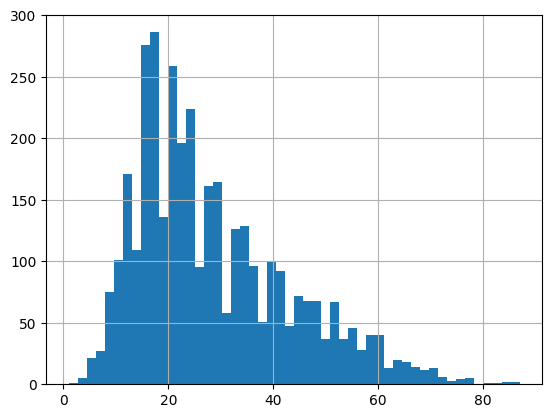

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows',10000)

# Read in the shark data

url='https://sharkattackfile.net/GSAF5.xls' # reading in the shark attack file
df = pd.read_excel(url) # assigning the data to a variable
df.head() # looking at the first few rows of the variable

#dropping any columns with all missing values and re-assigning it back to the variable
df = df.drop(columns=['pdf', 'href','href formula','Case Number','Case Number.1','original order','Unnamed: 21','Unnamed: 22'])
df.head()# checking the first few rows again

#cleaning the year variable
df = df[df['Year'] >= 1940.0] # anything after 1940

#checking to see if there is any years before 1940 still there
if (df["Year"] < 1940.0).any():
  print("didn't work")
else:
  pass
df['Year'].unique() # looking at all years that are reported amnd its
df['Year'].dtype # looking at the datatype
df['Year'] = pd.to_numeric(df['Year'], errors='coerce') # changing the data type to numeric
df['Year'] = df['Year'].replace(20026.0, 2026.0)# making the outlier the correct year

#print(df["Year"].value_counts().sort_index(), '\n') # checking the amount of each year is being reported and its trends, and sort them by year

# Clean the age variable
var = "Age" # assigning the age variable to a new variable name
#print(df[var].unique(), '\n')
#print(df[var].value_counts(), '\n')
# remove the NaN

df['age_nan'] = df[var].isnull() # making all the NaN data into one variable
df[var].dropna() # drop the Na's from the Age variable
#Making histogram
df[var] = pd.to_numeric(df[var], errors='coerce') #change elements to numeric
#print(df[var].value_counts(), '\n') # checking what elements are still present
df[var].hist(bins=50) # creating the histogram \


# looking at the gender
df.head() # using .head() to see first few rows --> checking the col name and elements
#print(df['Sex'].unique(),"Unique for `Sex`")
#print(df["Sex"].value_counts(), 'Value count for `Sex`')


#have to clean the variables in the sex column
var2 = "Sex"
df[var2] = df[var2].replace(" M","M")
df[var2] = df[var2].replace("m","M")
df[var2] = df[var2].replace("M ","M")
df[var2] = df[var2].replace("M x 2","M")
df[var2] = df[var2].replace("F ","F")
df[var2] = df[var2].replace("lli", np.nan)
df[var2] = df[var2].replace("?", np.nan)

#checking the proportion of provoked
total = 4362+725
#print((4362/total)*100,"%")
#print(df[var2].value_counts(), 'Value count for `Sex`')


# Cleaning the type variable
var3 = "Type"
df[var3].value_counts()

# Replacing each of the variables with an na that dont = the correct elements
df[var3] = df[var3].replace("Watercraft", np.nan)
df[var3] = df[var3].replace("Sea Disaster", np.nan)
df[var3] = df[var3].replace("Questionable", np.nan)
df[var3] = df[var3].replace("Boat", np.nan)
df[var3] = df[var3].replace("unprovoked", np.nan)
df[var3] = df[var3].replace("Unconfirmed", np.nan)
df[var3] = df[var3].replace("?", np.nan)
df[var3] = df[var3].replace("Unverified", np.nan)
df[var3] = df[var3].replace("Under investigation", np.nan)
df[var3] = df[var3].replace(" Provoked", np.nan)
#print(df[var3].value_counts())# checking everything was replaced

# checking the proportion of unprovoked
total_count = 4127+521+402
#print((4127/total_count)*100)

The trends across the years shows far fewer reported incidents in earlier years. Therefore, reported attacks are increasing over time.

Proportions:

*   85.75% of victims were men
*   81.72% of attacks were unprovoked





## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.
Phase 2 commit SHA ID: 2b3e1049c0ea7dd7dbb72cac5bc0db5633faf952

- **Phase 1 commit SHA ID:** 66dfc99ae33108a93b2ef14f453700547ca70e91
- **AI tool and model used:** Claude

### *Prompts used

##Question 1.1
1.for this file i want to clean the price variable as much as possible, how many missing values are there after the cleaning. Also what happens to the format of the price when it goes over 999 dollars. Give me a list of things you think i should audit give bullet points with code you suggest
#Question 1.2
1.
with this dataset clean the subject_injury variable, with also handling the NA, these values should say yes when a person was injured by police and no if  they were not injured. How much is actually missing. Also cross-tabulate this cleaned variable without eh force_type variable, are there any patterns for the data missing?
2. Give me a list of things you think i should audit give bullet points with code you suggest

#Question 2
1. extractug the GSAF5.xls file from this website: https://sharkattackfile.net/ read in the ata, drop all columns that do notr contain data, clean the eyear variable to focus on attacjs since 1940 and order them in ascending order. clean the age variable and make a histogram of the ages of the vistims accounting for all data reports and drop the nan., what porportion of victims are male, clean the type variable so it takes three values: Provoked and Unprovoked and Unknown how much is unprovoked

# *AI-proposed changes


Pasted the AI's concise numbered list verbatim.
## Question 1.1

 " Here's what's going on with the Price column:

Cleaning result

The raw Price column is read in as text (string), not numbers — because of the formatting issue below. Once you strip commas and convert to numeric:

python
import pandas as pd
df = pd.read_csv('airbnb_hw.csv')

Remove thousands-separator commas, then convert to numeric

df['Price_clean'] = df['Price'].astype(str).str.replace(',', '', regex=False)
df['Price_clean'] = pd.to_numeric(df['Price_clean'], errors='coerce')

print(df['Price_clean'].isna().sum())

Missing values after cleaning: 0. There were no true nulls or non-numeric junk in this column — every value converted cleanly once the commas were stripped.

What happens over $999

Any price of 1,000 or more gets a comma as a thousands separator (e.g. "1,990", "5,000", "10,000") written as text. Since a comma isn't a valid character in a numeric column, pandas can't parse the whole column as numbers and reads all of Price as a string/object dtype instead — even the sub-1,000 values that look numeric. That's why you have to strip the commas before pd.to_numeric will work. 181 rows in this dataset are affected (all values ≥ 1,000).

Things I'd audit next
Other numeric-looking columns stored as text/with formatting issues — check dtypes across the board, not just Price:
python

  df.dtypes
  df.select_dtypes(include='object').head()

Zipcode — it's stored as float (11249.0), which can silently truncate/mangle leading zeros or turn into scientific notation; check for weird values and consider casting to string:
python

  df['Zipcode'].apply(lambda x: len(str(int(x))) if pd.notna(x) else None).value_counts()

Host Since — check it parses as a real date and look for missing/invalid entries:
python

  pd.to_datetime(df['Host Since'], errors='coerce').isna().sum()

Review Scores Rating vs. Review Scores Rating (bin) — check consistency between the continuous and binned versions, and how much missingness each has:
python

  df['Review Scores Rating'].isna().sum()
  df['Review Scores Rating (bin)'].isna().sum()

Price outliers — a max of $10,000/night vs. a median of $125 is a huge spread; decide if extreme values are legit listings or data errors:
python

  df['Price_clean'].sort_values(ascending=False).head(20)

Beds / Number of Records / Number Of Reviews — check for 0s, negative values, or implausible values:
python

  (df['Beds'] <= 0).sum()

Neighbourhood column name has a trailing space ('Neighbourhood ') — easy source of silent bugs (KeyError or failed merges) if you reference it as 'Neighbourhood':
python

  df.columns = df.columns.str.strip()

Duplicate listings — check if Host Id or the whole row repeats unexpectedly:
python

  df.duplicated().sum()
  df['Host Id'].duplicated().sum()
  
  "

##Question 1.2
Here's what I'd check next on this dataset:

Missingness in other columns, not just subject_injury — is it concentrated in the same records/force types?
python

  df.isna().sum().sort_values(ascending=False)

Consistency between force_type and force_type_action — make sure the action detail always maps to a sensible parent category, no orphaned/mismatched pairs:
python

  pd.crosstab(df['force_type'], df['force_type_action']).T

race and sex coding — check for inconsistent labels, typos, or unknown/missing codes that need standardizing:
python

  df['race'].value_counts(dropna=False)
  df['sex'].value_counts(dropna=False)

age sanity check — look for impossible values (negative, 0, or implausibly high):
python

  df['age'].describe()
  df[(df['age'] < 0) | (df['age'] > 100)]

response_datetime parsing — confirm it converts cleanly to datetime and check the date range for gaps or errors:
python

  df['response_datetime_parsed'] = pd.to_datetime(df['response_datetime'], errors='coerce')
  df['response_datetime_parsed'].isna().sum()
  df['response_datetime_parsed'].min(), df['response_datetime_parsed'].max()

is_911_call coding — confirm it's a clean binary/boolean and check its missingness:
python

  df['is_911_call'].value_counts(dropna=False)

primary_offense free-text messiness — likely has many overlapping/near-duplicate categories (typos, different capitalization) that should be grouped:
python

  df['primary_offense'].value_counts(dropna=False).head(30)

precinct vs neighborhood consistency — check that neighborhoods map to sensible/consistent precincts (no impossible combinations):
python

  df.groupby('precinct')['neighborhood'].nunique()

Duplicate incident records — check for exact duplicate rows that could inflate counts:
python
  df.duplicated().sum()

type_resistance missingness and categories, and whether it correlates with subject_injury missingness the same way force_type did:
python

  df['type_resistance'].value_counts(dropna=False)
  pd.crosstab(df['type_resistance'], df['subject_injury_clean'])
## Question 2
"Please download GSAF5.xls yourself from the site and upload it here — once it's uploaded I can run everything in one go. Here's the full script ready to go the moment you upload it, covering every step you asked for:

python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 1. Load
df = pd.read_excel('GSAF5.xls')

2. Drop columns that contain no data at all
df = df.dropna(axis=1, how='all')

3. Clean Year: coerce to numeric, filter to 1940+, sort ascending
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df[df['Year'] >= 1940]
df = df.sort_values('Year', ascending=True)

4. Clean Age: pull out the numeric portion, coerce, drop missing for the histogram
df['Age_clean'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
ages = df['Age_clean'].dropna()

plt.figure(figsize=(8,5))
plt.hist(ages, bins=30, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of victims')
plt.title('Distribution of Shark Attack Victim Ages (1940–present)')
plt.show()

 5. Proportion male
df['Sex_clean'] = df['Sex'].astype(str).str.strip().str.upper()
df['Sex_clean'] = df['Sex_clean'].where(df['Sex_clean'].isin(['M','F']), np.nan)
pct_male = df['Sex_clean'].value_counts(normalize=True, dropna=True).get('M')
print('Proportion male:', pct_male)

 6. Clean Type to 3 categories: Provoked / Unprovoked / Unknown
def clean_type(x):
    x = str(x).strip().lower()
    if x == 'provoked':
        return 'Provoked'
    elif x == 'unprovoked':
        return 'Unprovoked'
    else:
        return 'Unknown'

df['Type_clean'] = df['Type'].apply(clean_type)
print(df['Type_clean'].value_counts())

pct_unprovoked = (df['Type_clean'] == 'Unprovoked').mean()
print('Proportion unprovoked:', pct_unprovoked)

A few honest caveats built into this so you know what to check once you see real output:

Age: some entries are ranges ("30s", "teen", "20 or 30") — the regex grabs the first number it finds, which is a reasonable simplification but worth spot-checking.
Type: anything that isn't exactly "Provoked" or "Unprovoked" (e.g. "Questionable," "Invalid," "Boat," blank) collapses into "Unknown" — that's a judgment call, let me know if you want a different mapping.

Once you upload the file, I'll actually run this and give you the real numbers instead of a script."


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / **reject** | The output is looking into way to many varaibles, however it does answer the initial question. I think my code and the AI code is very similar in response to the question, therefore I wont change anything . This is the same for both question 1.1 and 1.2.|
| 2 | Accept / **modify** / reject | Again just gave way to much information in my opinion. It is looking at things that are excessive. However, i think that it produced a way better way for clenaing the age, sex, and type so I would implement those and keep the rest of my code|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
# Question 2

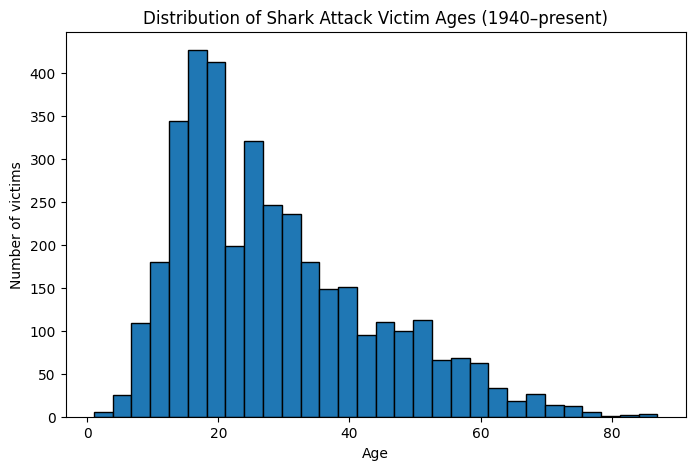

Proportion male: 0.857451828548958
Type_clean
Unprovoked    4128
Unknown        889
Provoked       523
Name: count, dtype: int64
Proportion unprovoked: 0.7451263537906138


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows',10000)

# Read in the shark data

url='https://sharkattackfile.net/GSAF5.xls' # reading in the shark attack file
df = pd.read_excel(url) # assigning the data to a variable
df.head() # looking at the first few rows of the variable

#dropping any columns with all missing values and re-assigning it back to the variable
df = df.drop(columns=['pdf', 'href','href formula','Case Number','Case Number.1','original order','Unnamed: 21','Unnamed: 22'])
df.head()# checking the first few rows again

#cleaning the year variable
df = df[df['Year'] >= 1940.0] # anything after 1940

#checking to see if there is any years before 1940 still there
if (df["Year"] < 1940.0).any():
  print("didn't work")
else:
  pass
df['Year'].unique() # looking at all years that are reported amnd its
df['Year'].dtype # looking at the datatype
df['Year'] = pd.to_numeric(df['Year'], errors='coerce') # changing the data type to numeric
df['Year'] = df['Year'].replace(20026.0, 2026.0)# making the outlier the correct year

#print(df["Year"].value_counts().sort_index(), '\n') # checking the amount of each year is being reported and its trends, and sort them by year

# ------ The AI generated code ---------
# 4. Clean Age: pull out the numeric portion, coerce, drop missing for the histogram
df['Age_clean'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
ages = df['Age_clean'].dropna()

plt.figure(figsize=(8,5))
plt.hist(ages, bins=30, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of victims')
plt.title('Distribution of Shark Attack Victim Ages (1940–present)')
plt.show()

# 5. Proportion male
df['Sex_clean'] = df['Sex'].astype(str).str.strip().str.upper()
df['Sex_clean'] = df['Sex_clean'].where(df['Sex_clean'].isin(['M','F']), np.nan)
pct_male = df['Sex_clean'].value_counts(normalize=True, dropna=True).get('M')
print('Proportion male:', pct_male)

# 6. Clean Type to 3 categories: Provoked / Unprovoked / Unknown
def clean_type(x):
    x = str(x).strip().lower()
    if x == 'provoked':
        return 'Provoked'
    elif x == 'unprovoked':
        return 'Unprovoked'
    else:
        return 'Unknown'

df['Type_clean'] = df['Type'].apply(clean_type)
print(df['Type_clean'].value_counts())

pct_unprovoked = (df['Type_clean'] == 'Unprovoked').mean()
print('Proportion unprovoked:', pct_unprovoked)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements that AI gave me were the ability to effectively clean the columns that had much messier data in the Shark Attack dataset. The AI chatbot was able to simplify the code into a couple of lines, compared to my excessive amount of code to get the correct answer. This made the whole cleaning process faster and less crowded. This is mainly due to my lack of full knowledge of python, as an R user, so having a program that could understand my intent and turn it into working Python code saved a significant amount of time and reduced the number of errors I ran into along the way. However, with the other two questions, I didn't see the AI's output as useful or necessary. It looked at multiple variables that I didn't prompt it to look at, and did way more work than what was needed, which made the response not relevant for the actual answer. Therefore, in that case, the AI was not a beneficial use of the code, and I found it more efficient to use my own code.